# Notebook Purpose

DEPRECATED: Historical two-stage (ALS + ranker) experiment kept for comparison; not used in production.


## Workflow

Setup, run, evaluate, and save outputs.


In [7]:
# Cell 1: Imports (reload to pick up fixed code)
import importlib
import sys
sys.path.append('..')

import src.models.two_stage
importlib.reload(src.models.two_stage)

from src.models.two_stage import TwoStageRecommender, compare_single_stage_vs_two_stage
from src.models.baselines import LGBMBaseline, evaluate_model
import pandas as pd
import numpy as np

print("Imports successful")


Imports successful


In [8]:
# Cell 2: Load data and trained model

print("Loading data...")
train_df = pd.read_parquet('../data/processed/train_dataset.parquet')
val_df = pd.read_parquet('../data/processed/val_dataset.parquet')
prior_data = pd.read_parquet('../data/processed/prior_orders.parquet')

print(f"✅ Train: {train_df.shape}")
print(f"✅ Val: {val_df.shape}")
print(f"✅ Prior: {prior_data.shape}")

# Load pre-trained LightGBM model
print("\nLoading pre-trained LightGBM model...")

import joblib
lgbm_model = joblib.load('../models/saved/lgbm_baseline.pkl')

print("✅ LightGBM model loaded")
print(f"   Best iteration: {lgbm_model.model.best_iteration}")
print(f"   Number of features: {len(lgbm_model.feature_cols)}")


Loading data...
✅ Train: (6777721, 22)
✅ Val: (1696940, 22)
✅ Prior: (32434489, 9)

Loading pre-trained LightGBM model...
✅ LightGBM model loaded
   Best iteration: 491
   Number of features: 19


In [9]:
# Cell 3: Train ALS with ALL products
print("Collecting all product IDs...")

# Get all products from val set
all_products_in_data = set(val_df['product_id'].unique())

print(f"Total unique products: {len(all_products_in_data)}")

# Create two-stage model
two_stage = TwoStageRecommender(
    ranker_model=lgbm_model,
    n_candidates=500,
    als_factors=100
)

# Train ALS with ALL products in vocabulary
two_stage.fit_als(
    prior_data[['user_id', 'product_id']],
    all_products=all_products_in_data
)

print(f"\n✅ ALS trained with complete product vocabulary")


Total unique products: 43135
Training ALS for candidate generation...
  Users: 206,209
  Products: 49,677
  Matrix shape: (206209, 49677)
  Sparsity: 0.998701


  0%|          | 0/15 [00:00<?, ?it/s]

ALS training completed

✅ ALS trained with complete product vocabulary


In [10]:
# Cell 4: Evaluate Stage 1 Recall
# Important: Check if candidates contain most true positives
stage1_recall = two_stage.evaluate_stage1_recall(val_df, val_df['reordered'])


Evaluating Stage 1 recall...
  Stage 1 Recall: 0.7393
  (i.e., 73.9% of true reorders are in candidates)


In [11]:
# Cell 5: FAIR COMPARISON: Only on user's historical products

# Filter val_df to only user-product pairs from prior
# (i.e., only products the user has bought before)
val_with_history = val_df[val_df['up_times_bought'] > 0].copy()

print(f"\nOriginal val set: {len(val_df)} pairs")
print(f"Val set (user history only): {len(val_with_history)} pairs")
print(f"Filtered out {len(val_df) - len(val_with_history)} pairs (new products)")

y_val_filtered = val_with_history['reordered']

# Now compare on this filtered set
print("\n" + "="*60)
print("SINGLE-STAGE (on user history)")
print("="*60)

import time
start = time.time()
y_pred_single = lgbm_model.predict(val_with_history)
single_time = time.time() - start

print(f"  Time: {single_time:.2f}s")
print(f"  Predictions: {len(y_pred_single)}")

# Two-stage
print("\n" + "="*60)
print("TWO-STAGE (on user history)")
print("="*60)

y_pred_two, info = two_stage.predict(val_with_history, return_candidates=True)

print(f"  Candidate coverage: {info['coverage']:.1%}")
print(f"  Time: {info['total_time']:.2f}s")

# Evaluate
from sklearn.metrics import roc_auc_score, f1_score

# Single-stage metrics
best_f1_single = 0
best_thresh_single = 0.5

for thresh in np.arange(0.1, 0.6, 0.05):
    f1 = f1_score(y_val_filtered, (y_pred_single >= thresh).astype(int))
    if f1 > best_f1_single:
        best_f1_single = f1
        best_thresh_single = thresh

# Two-stage metrics
best_f1_two = 0
best_thresh_two = 0.5

for thresh in np.arange(0.1, 0.6, 0.05):
    f1 = f1_score(y_val_filtered, (y_pred_two >= thresh).astype(int))
    if f1 > best_f1_two:
        best_f1_two = f1
        best_thresh_two = thresh

print("\n" + "="*60)
print("RESULTS (Fair Comparison)")
print("="*60)

results = pd.DataFrame({
    'Metric': ['AUC', 'Best F1', 'Best Threshold', 'Latency (s)', 'Speedup'],
    'Single-Stage': [
        f"{roc_auc_score(y_val_filtered, y_pred_single):.4f}",
        f"{best_f1_single:.4f}",
        f"{best_thresh_single:.2f}",
        f"{single_time:.2f}",
        "1.0x"
    ],
    'Two-Stage': [
        f"{roc_auc_score(y_val_filtered, y_pred_two):.4f}",
        f"{best_f1_two:.4f}",
        f"{best_thresh_two:.2f}",
        f"{info['total_time']:.2f}",
        f"{single_time / info['total_time']:.1f}x"
    ]
})

print(results.to_string(index=False))



Original val set: 1696940 pairs
Val set (user history only): 1696940 pairs
Filtered out 0 pairs (new products)

SINGLE-STAGE (on user history)
  Time: 2.80s
  Predictions: 1696940

TWO-STAGE (on user history)
Running two-stage prediction...
  Stage 1: Generating candidates...
    Generated 942788 candidates from 1696940 pairs
    Candidate coverage: 55.6%
    Stage 1 time: 40.74s
  Stage 2: Ranking candidates...
    Stage 2 time: 1.91s
  Total time: 42.65s
  Avg time per user: 1.6ms
  Candidate coverage: 55.6%
  Time: 42.65s

RESULTS (Fair Comparison)
        Metric Single-Stage Two-Stage
           AUC       0.8315    0.7263
       Best F1       0.4358    0.4045
Best Threshold         0.20      0.20
   Latency (s)         2.80     42.65
       Speedup         1.0x      0.1x


In [12]:
# Cell 6: Visualize Trade-offs
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score

y_val = val_df['reordered']

# Try different numbers of candidates
print("Testing different candidate sizes...")

candidate_sizes = [100, 200, 300, 500, 1000]
metrics = []

for n in candidate_sizes:
    print(f"\nTesting n_candidates={n}...")
    
    two_stage_temp = TwoStageRecommender(
        ranker_model=lgbm_model,
        n_candidates=n,
        als_factors=100
    )
    two_stage_temp.als_model = two_stage.als_model
    two_stage_temp.user_id_map = two_stage.user_id_map
    two_stage_temp.product_id_map = two_stage.product_id_map
    two_stage_temp.reverse_product_map = two_stage.reverse_product_map
    two_stage_temp.user_item_matrix = two_stage.user_item_matrix
    
    y_pred, info = two_stage_temp.predict(val_df, return_candidates=True)
    
    # Find best F1
    best_f1 = 0
    for thresh in np.arange(0.1, 0.6, 0.05):
        f1 = f1_score(y_val, (y_pred >= thresh).astype(int))
        if f1 > best_f1:
            best_f1 = f1
    
    metrics.append({
        'n_candidates': n,
        'coverage': info['coverage'],
        'auc': roc_auc_score(y_val, y_pred),
        'f1': best_f1,
        'latency': info['total_time']
    })

metrics_df = pd.DataFrame(metrics)
print("\n" + "="*60)
print(metrics_df)


Testing different candidate sizes...

Testing n_candidates=100...
Running two-stage prediction...
  Stage 1: Generating candidates...
    Generated 569714 candidates from 1696940 pairs
    Candidate coverage: 33.6%
    Stage 1 time: 10.03s
  Stage 2: Ranking candidates...
    Stage 2 time: 1.04s
  Total time: 11.07s
  Avg time per user: 0.4ms

Testing n_candidates=200...
Running two-stage prediction...
  Stage 1: Generating candidates...
    Generated 720769 candidates from 1696940 pairs
    Candidate coverage: 42.5%
    Stage 1 time: 17.53s
  Stage 2: Ranking candidates...
    Stage 2 time: 1.16s
  Total time: 18.69s
  Avg time per user: 0.7ms

Testing n_candidates=300...
Running two-stage prediction...
  Stage 1: Generating candidates...
    Generated 816164 candidates from 1696940 pairs
    Candidate coverage: 48.1%
    Stage 1 time: 24.58s
  Stage 2: Ranking candidates...
    Stage 2 time: 1.30s
  Total time: 25.88s
  Avg time per user: 1.0ms

Testing n_candidates=500...
Running tw

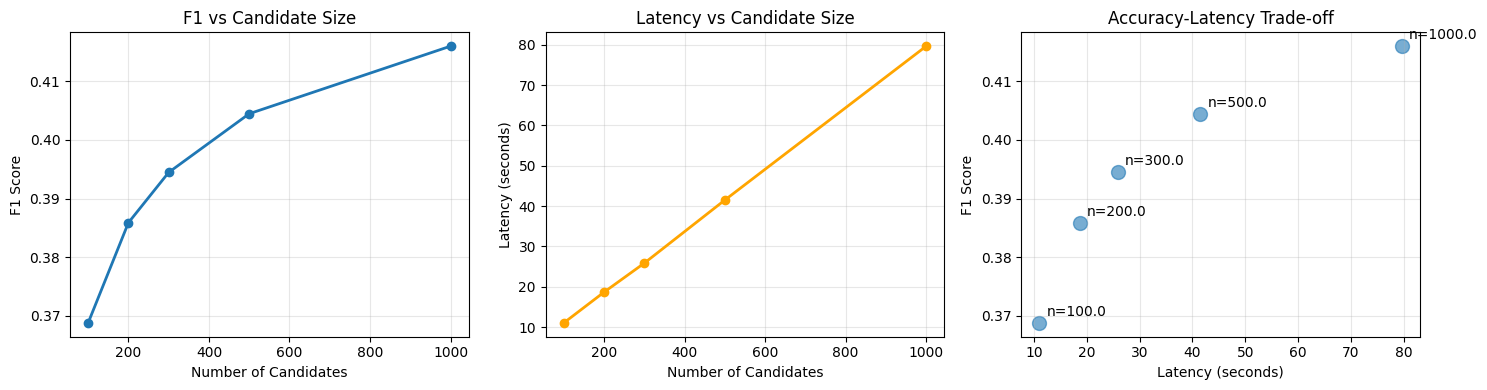

In [13]:
# Cell 7: Plot Trade-off Curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# F1 vs candidates
axes[0].plot(metrics_df['n_candidates'], metrics_df['f1'], marker='o', linewidth=2)
axes[0].set_xlabel('Number of Candidates')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 vs Candidate Size')
axes[0].grid(True, alpha=0.3)

# Latency vs candidates
axes[1].plot(metrics_df['n_candidates'], metrics_df['latency'], marker='o', linewidth=2, color='orange')
axes[1].set_xlabel('Number of Candidates')
axes[1].set_ylabel('Latency (seconds)')
axes[1].set_title('Latency vs Candidate Size')
axes[1].grid(True, alpha=0.3)

# F1 vs Latency (Pareto frontier)
axes[2].scatter(metrics_df['latency'], metrics_df['f1'], s=100, alpha=0.6)
for i, row in metrics_df.iterrows():
    axes[2].annotate(f"n={row['n_candidates']}", 
                     (row['latency'], row['f1']),
                     xytext=(5, 5), textcoords='offset points')
axes[2].set_xlabel('Latency (seconds)')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Accuracy-Latency Trade-off')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/two_stage_tradeoffs.png', dpi=150, bbox_inches='tight')
plt.show()
